# Edge Online learning for watrer level prediction

In [2]:
# !git clone https://github.com/omardwahba/water_lvl_pred
# import os
# os.chdir('/content/water_lvl_pred/water_lvl_pred')


In [3]:
# pip install -r requirements.txt

In [4]:
# import torch.optim as optim
import pandas as pd
import numpy as np
import util_fun as uf
from cstm_models import build_mlp 

### Training parameter

In [5]:
# model parameters
LOOKBACK = 48   # 48 h of historical data for prediction
HORIZON = 24    # 24 h of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  
H_BAR_INDEX = 3 
EPSILON = 1e-6  # For numerical stability in normalization



In [6]:
train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by pytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)



<class 'pandas.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)


In [7]:
# --- No-leakage sequences (step = LOOKBACK + HORIZON = 72) ---
x_train_72, y_train_72 = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)
x_test_72,  y_test_72  = uf.create_sequences(test_df.values.astype(np.float32),  LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)

train_ds_72 = uf.RollingNormTimeSeriesDataset(x_train_72, y_train_72, H_BAR_INDEX)
test_ds_72  = uf.RollingNormTimeSeriesDataset(x_test_72,  y_test_72,  H_BAR_INDEX)

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 59112.
Total sequences created: 821
 X shape: (821, 48, 4), y shape: (821, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 17496.
Total sequences created: 243
 X shape: (243, 48, 4), y shape: (243, 24)


## Online Training using ADAM


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 7.334490
   Batch 200/2461, Loss: 0.133896
   Batch 300/2461, Loss: 0.043459
   Batch 400/2461, Loss: 0.436516
   Batch 500/2461, Loss: 0.070214
   Batch 600/2461, Loss: 0.033488
   Batch 700/2461, Loss: 3.977854
   Batch 800/2461, Loss: 0.132575
   Batch 900/2461, Loss: 23.574585
   Batch 1000/2461, Loss: 2.940021
   Batch 1100/2461, Loss: 0.246768
   Batch 1200/2461, Loss: 0.376379
   Batch 1300/2461, Loss: 0.155571
   Batch 1400/2461, Loss: 2.176399
   Batch 1500/2461, Loss: 0.010122
   Batch 1600/2461, Loss: 0.338040
   Batch 1700/2461, Loss: 0.773293
   Batch 1800/2461, Loss: 0.320029
   Batch 1900/2461, Loss: 5.085118
   Batch 2000/2461, Loss: 0.341641
   Batch 2100/2461, Loss: 1.589293
   Batch 2200/2461, Loss: 0.059240
   Batch 2300/2461, Loss: 0.072720
   Batch 2400/2461, Loss: 0.311310
   Batch 2461/2461, Loss: 1.159043
Training complete.


============== FINAL COMPARISON ==============
online-ADAM     

Saved PNG: results/training\Online Learning Training Results.png


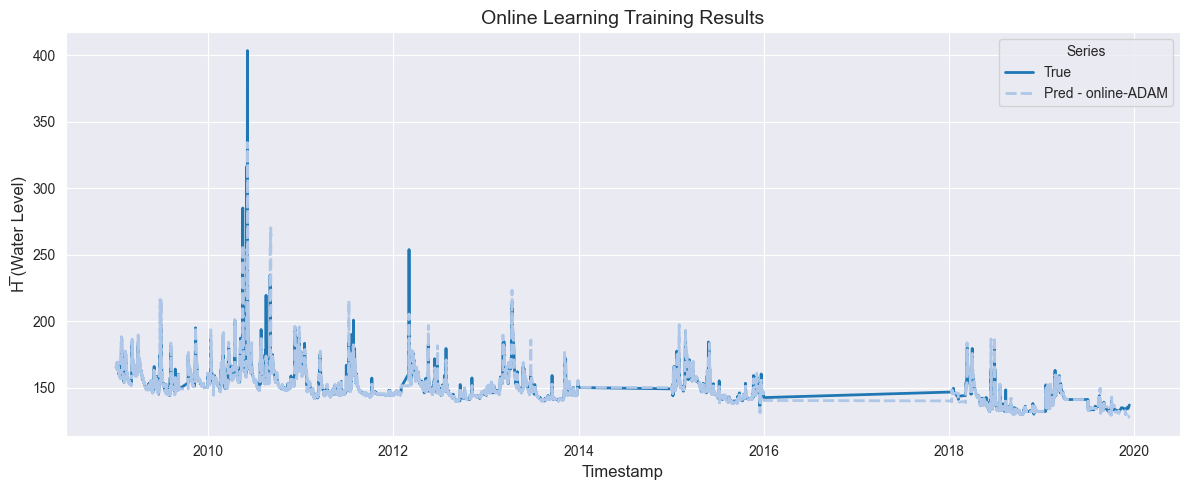

Appended metrics to CSV: results/training\Online Learning Training Results.csv


In [8]:
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Online Learning Training Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/training/Online Learning Training Results')

Testing complete.


============== FINAL COMPARISON ==============
online-ADAM          | RMSE=3.5692 | MAE=0.9434 | R²=0.8933


Saved PNG: results/testing/online\Online Learning MLP test.png


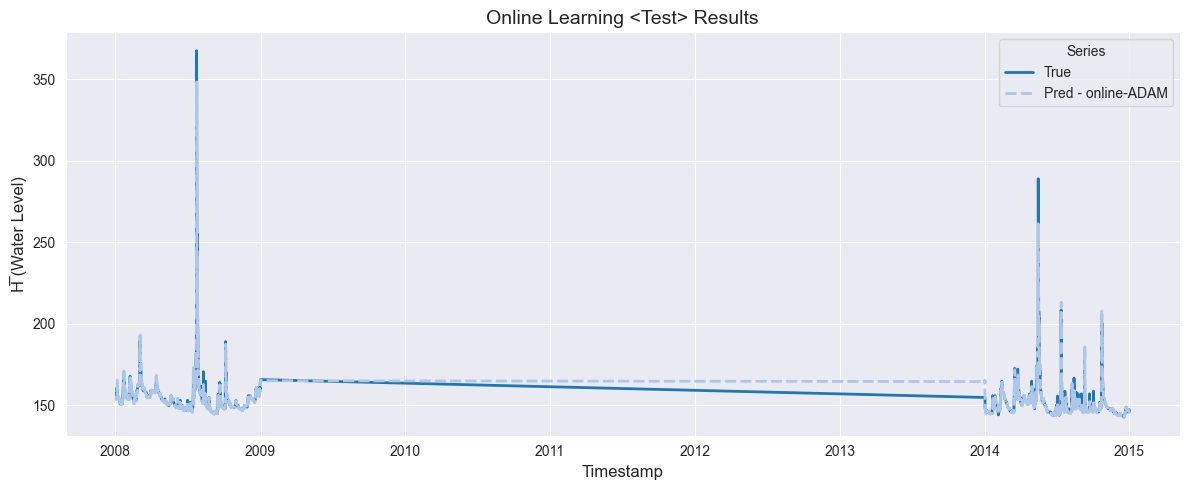

Appended metrics to CSV: results/testing/online\Online Learning MLP test.csv
Exported results to CSV: results/testing/predictions_vs_true/online_MLP.csv


In [9]:
# evaluation on test set
y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
uf.calculate_metrics_and_plot({"online-ADAM": (y_true_test, y_pred_test, time_indices_test)},
                              plot_title = 'Online Learning <Test> Results',
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/testing/online/Online Learning MLP test')
# Save predictions to CSV files to be used later in Experiments
uf.export_results_to_csv({"MLP": (y_true_test, y_pred_test,time_indices_test)}, 
                         "results/testing/predictions_vs_true/online")
    


Starting 'online' training with 821 batches...
   Batch 100/821, Loss: 2.830444
   Batch 200/821, Loss: 15.506995
   Batch 300/821, Loss: 0.128333
   Batch 400/821, Loss: 0.231484
   Batch 500/821, Loss: 7.038416
   Batch 600/821, Loss: 1.797245
   Batch 700/821, Loss: 0.076405
   Batch 800/821, Loss: 0.962187
   Batch 821/821, Loss: 2.636771
Training complete.
Testing complete.


============== FINAL COMPARISON ==============
online-ADAM s24 (original) | RMSE=3.5692 | MAE=0.9434 | R²=0.8933
online-ADAM s72 (no-leak) | RMSE=4.2055 | MAE=1.0706 | R²=0.8338


Saved PNG: results/testing/online\Online_step_comparison.png


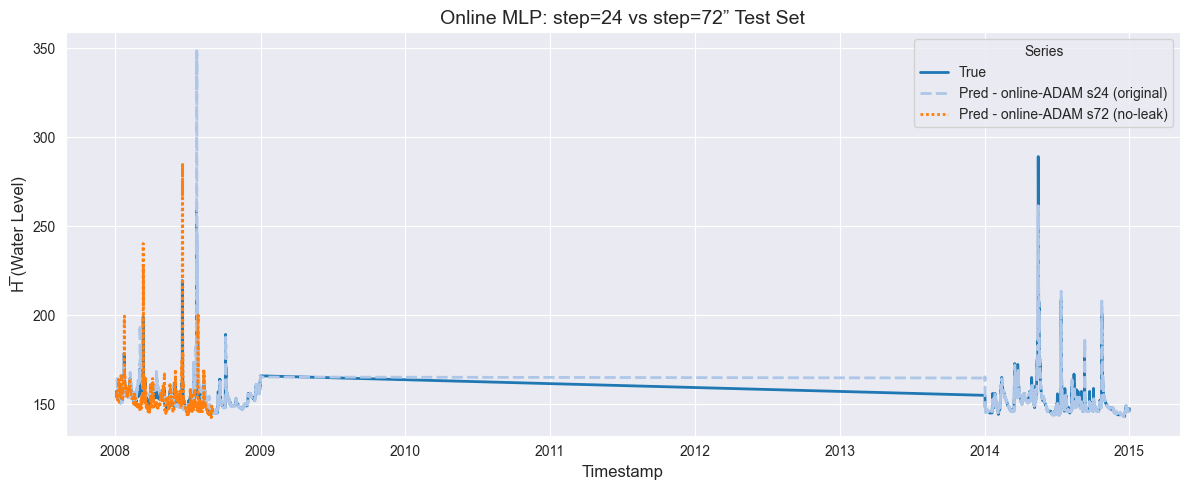

Appended metrics to CSV: results/testing/online\Online_step_comparison.csv


In [10]:
# --- Train & evaluate with step=72 (no leakage) ---
model_72, optimizer_72, criterion_72 = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true_72, y_pred_72, time_indices_72, _ = uf.train_model_online(model_72, optimizer_72, criterion_72,
                                                                   train_ds_72, train_df,
                                                                   LOOKBACK, HORIZON, BATCH_SIZE)

y_true_test_72, y_pred_test_72, time_indices_test_72 = uf.model_evaluate_with_norm(model_72, criterion_72,
                                                                                    test_ds_72, test_df.index,
                                                                                    LOOKBACK, HORIZON, BATCH_SIZE)

# --- Compare step=24 (original) vs step=72 (no leakage) on test set ---
uf.calculate_metrics_and_plot(
    {
        "online-ADAM s24 (original)": (y_true_test,    y_pred_test,    time_indices_test),
        "online-ADAM s72 (no-leak)":  (y_true_test_72, y_pred_test_72, time_indices_test_72),
    },
    plot_title="Online MLP: step=24 vs step=72” Test Set",
    export_metrics=True,
    export_html=True,
    export_file_name='results/testing/online/Online_step_comparison'
)

## Testing Always updating
See model behaviour if we allowed it to learn on the fly from the testing data.<br>
**conclusion**<br>
Model's performance metrics went up as we all model to optimize and generalize more. In contarst model ability to adapt in lowered.<br>
We need to investigate more about optimizers and the adaptability, generalization trade-off.


Starting 'online' training with 728 batches...
   Batch 100/728, Loss: 23.995003
   Batch 200/728, Loss: 7.967453
   Batch 300/728, Loss: 0.205994
   Batch 400/728, Loss: 0.625785
   Batch 500/728, Loss: 0.092392
   Batch 600/728, Loss: 0.115971
   Batch 700/728, Loss: 0.124264
   Batch 728/728, Loss: 16.389519
Training complete.


============== FINAL COMPARISON ==============
online-MLP           | RMSE=3.5520 | MAE=1.0677 | R²=0.8943


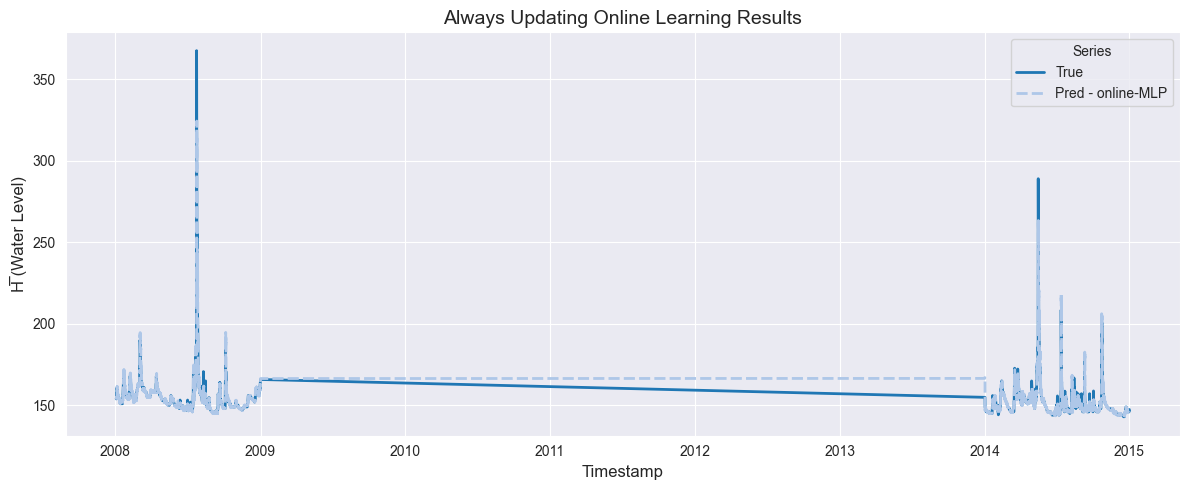

In [11]:
# Testing with always updating 
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              test_ds, test_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-MLP": (y_true, y_pred, time_indices)}, 
                              plot_title="Always Updating Online Learning Results")

# Phase 1: Normalization Experiments (Leak Fix + Stability)
> **Goal:** find the normalization that keeps `y_scaled` stable after the leak fix.
> All runs use Adam (lr=1e-3) + MLP so only the dataset class changes.

## 1.2 RollingNorm + y_clip (Leak-Fixed Baseline)


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 7.106125
   Batch 200/2461, Loss: 0.126422
   Batch 300/2461, Loss: 0.091748
   Batch 400/2461, Loss: 0.549933
   Batch 500/2461, Loss: 0.052715
   Batch 600/2461, Loss: 0.029357
   Batch 700/2461, Loss: 4.250499
   Batch 800/2461, Loss: 0.165458
   Batch 900/2461, Loss: 23.432665
   Batch 1000/2461, Loss: 3.095543
   Batch 1100/2461, Loss: 0.201684
   Batch 1200/2461, Loss: 0.404784
   Batch 1300/2461, Loss: 0.153088
   Batch 1400/2461, Loss: 2.070336
   Batch 1500/2461, Loss: 0.011127
   Batch 1600/2461, Loss: 0.312082
   Batch 1700/2461, Loss: 1.014915
   Batch 1800/2461, Loss: 0.416049
   Batch 1900/2461, Loss: 5.171189
   Batch 2000/2461, Loss: 0.311837
   Batch 2100/2461, Loss: 1.606928
   Batch 2200/2461, Loss: 0.052426
   Batch 2300/2461, Loss: 0.225841
   Batch 2400/2461, Loss: 0.429502
   Batch 2461/2461, Loss: 1.137858
Training complete.


============== FINAL COMPARISON ==============
RollingNorm+clip

Saved PNG: results/training/online\p1_rolling_clip.png


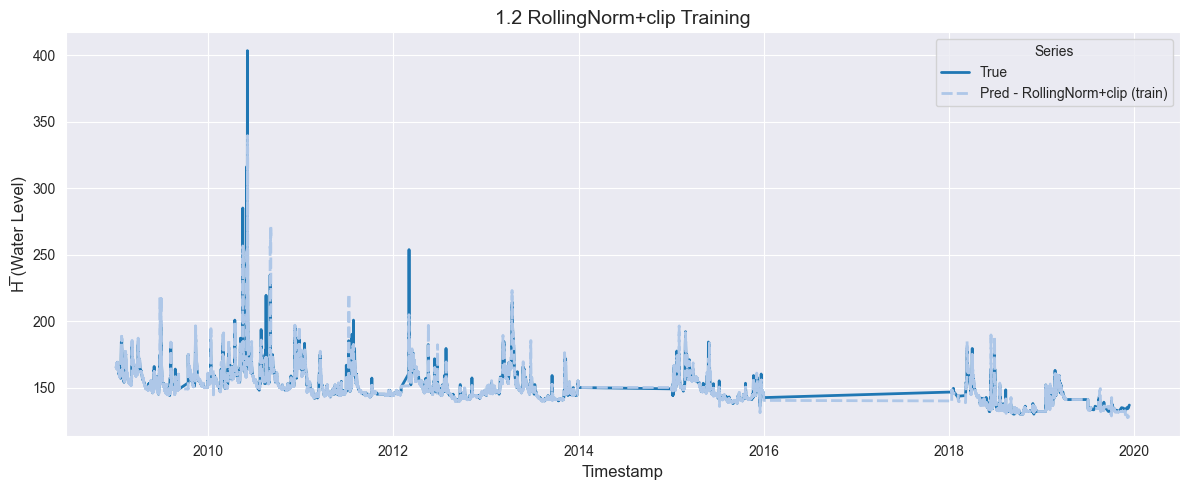

Appended metrics to CSV: results/training/online\p1_rolling_clip.csv


In [12]:
import torch
torch.manual_seed(42)

# RollingNorm with y_scaled clamped to [-5, 5]” leak fixed, same Adam baseline
train_ds_roll = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX, y_clip=5.0)
test_ds_roll  = uf.RollingNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX, y_clip=5.0)

model_roll, opt_roll, crit_roll = build_mlp(LOOKBACK * N_FEATURES, HORIZON)

y_tr_roll, y_pr_roll, idx_roll, losses_roll = uf.train_model_online(
    model_roll, opt_roll, crit_roll,
    train_ds_roll, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
)

uf.calculate_metrics_and_plot(
    {"RollingNorm+clip (train)": (y_tr_roll, y_pr_roll, idx_roll)},
    plot_title="1.2 RollingNorm+clip Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p1_rolling_clip",
)

Testing complete.


============== FINAL COMPARISON ==============
RollingNorm+clip     | RMSE=3.6945 | MAE=0.9475 | R²=0.8857


Saved PNG: results/testing/online\p1_rolling_clip.png


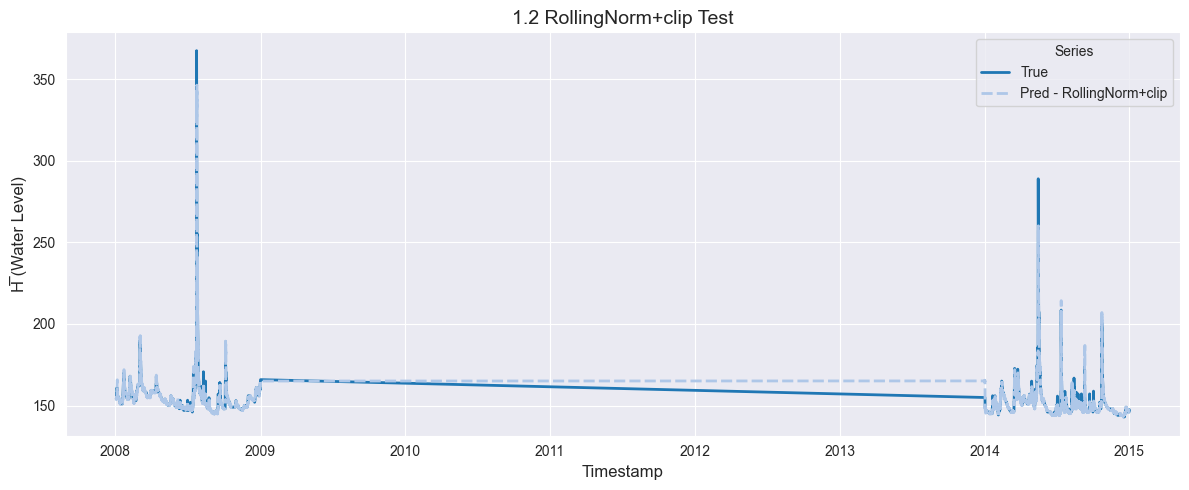

Appended metrics to CSV: results/testing/online\p1_rolling_clip.csv
Exported results to CSV: results/testing/predictions_vs_true/online_RollingNorm_clip.csv


In [13]:
y_te_roll, y_pe_roll, idx_te_roll = uf.model_evaluate_with_norm(
    model_roll, crit_roll, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)

uf.calculate_metrics_and_plot(
    {"RollingNorm+clip": (y_te_roll, y_pe_roll, idx_te_roll)},
    plot_title="1.2 RollingNorm+clip Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p1_rolling_clip",
)
uf.export_results_to_csv(
    {"RollingNorm_clip": (y_te_roll, y_pe_roll, idx_te_roll)},
    "results/testing/predictions_vs_true/online"
)

Saved: results/testing/online/p1_rolling_clip_diagnostic_RollingNorm+clip_diagnostic.png


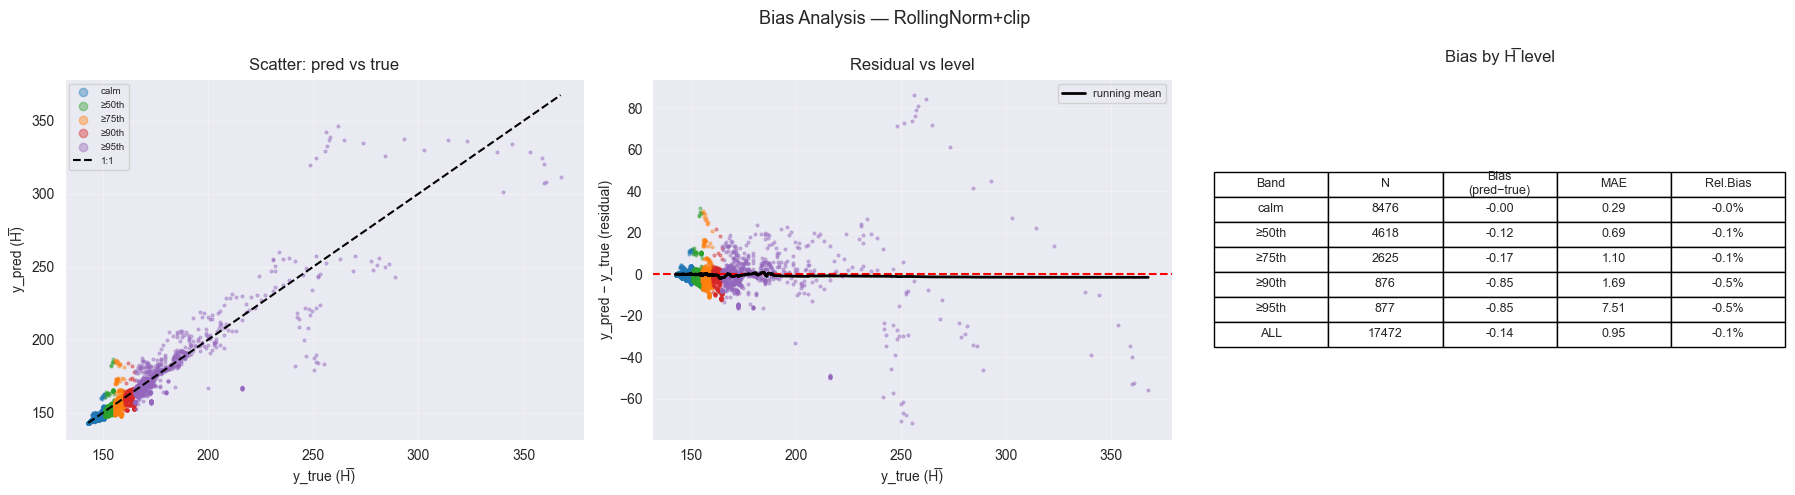

In [14]:
import importlib
importlib.reload(uf)

# Bias analysis: scatter + residual vs level + per-band stats table
uf.diagnostic_plot(
    {"RollingNorm+clip": (y_te_roll, y_pe_roll, idx_te_roll)},
    export_file_name="results/testing/online/p1_rolling_clip_diagnostic",
)

## 1.3: ZScore Normalization + Adam

In [15]:
# torch.manual_seed(42)

# train_ds_zscore = uf.ZScoreNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
# test_ds_zscore  = uf.ZScoreNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX)

# model_zs, opt_zs, crit_zs = build_mlp(LOOKBACK * N_FEATURES, HORIZON)

# y_tr_zs, y_pr_zs, idx_zs, losses_zs = uf.train_model_online(
#     model_zs, opt_zs, crit_zs,
#     train_ds_zscore, train_df,
#     LOOKBACK, HORIZON, BATCH_SIZE,
# )

# uf.calculate_metrics_and_plot(
#     {"ZScore (train)": (y_tr_zs, y_pr_zs, idx_zs)},
#     plot_title="1.3 ZScore Norm Training",
#     export_metrics=True, export_html=True,
#     export_file_name="results/training/online/p1_zscore",
# )

In [16]:
# y_te_zs, y_pe_zs, idx_te_zs = uf.model_evaluate_with_norm(
#     model_zs, crit_zs, test_ds_zscore, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
# )

# uf.calculate_metrics_and_plot(
#     {"ZScore": (y_te_zs, y_pe_zs, idx_te_zs)},
#     plot_title="1.3 ZScore Norm” Test",
#     export_metrics=True, export_html=True,
#     export_file_name="results/testing/online/p1_zscore",
# )
# uf.export_results_to_csv(
#     {"ZScore": (y_te_zs, y_pe_zs, idx_te_zs)},
#     "results/testing/predictions_vs_true/online"
# )

## 1.1 : Percentile Norm (5th/95th) + Adam

In [17]:
# torch.manual_seed(42)

# train_ds_pct = uf.PercentileNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX, y_clip=5.0)
# test_ds_pct  = uf.PercentileNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX, y_clip=5.0)

# model_pct, opt_pct, crit_pct = build_mlp(LOOKBACK * N_FEATURES, HORIZON)

# y_tr_pct, y_pr_pct, idx_pct, losses_pct = uf.train_model_online(
#     model_pct, opt_pct, crit_pct,
#     train_ds_pct, train_df,
#     LOOKBACK, HORIZON, BATCH_SIZE,
# )

# uf.calculate_metrics_and_plot(
#     {"Percentile (train)": (y_tr_pct, y_pr_pct, idx_pct)},
#     plot_title="1.1 Percentile Norm” Training",
#     export_metrics=True, export_html=True,
#     export_file_name="results/training/online/p1_percentile",
# )

In [18]:
# y_te_pct, y_pe_pct, idx_te_pct = uf.model_evaluate_with_norm(
#     model_pct, crit_pct, test_ds_pct, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
# )

# uf.calculate_metrics_and_plot(
#     {"Percentile": (y_te_pct, y_pe_pct, idx_te_pct)},
#     plot_title="1.1 Percentile Norm” Test",
#     export_metrics=True, export_html=True,
#     export_file_name="results/testing/online/p1_percentile",
# )
# uf.export_results_to_csv(
#     {"Percentile": (y_te_pct, y_pe_pct, idx_te_pct)},
#     "results/testing/predictions_vs_true/online"
# )

## Phase 1 Summary” All Normalisations vs Test Set

In [19]:
# uf.calculate_metrics_and_plot(
#     {
#         "RollingNorm+clip": (y_te_roll, y_pe_roll, idx_te_roll),
#         "ZScore":           (y_te_zs,   y_pe_zs,   idx_te_zs),
#         "Percentile":       (y_te_pct,  y_pe_pct,  idx_te_pct),
#     },
#     plot_title="Phase” Normalisation Comparison (Test Set)",
#     export_metrics=True, export_html=True,
#     export_file_name="results/testing/online/phase1_norm_comparison",
# )

# Phase 2: Optimizer Experiments
> Uses the **best normalization from Phase 1** (swap `BEST_TRAIN_DS` / `BEST_TEST_DS` below).
> All other params fixed. Each cell is self-contained â€” run independently.

In [20]:
# Phase 1 winner: RollingNorm+clip — use these for all Phase 2 experiments
BEST_TRAIN_DS = train_ds_roll   # RollingNormTimeSeriesDataset with y_clip=5.0
BEST_TEST_DS  = test_ds_roll    # matching test dataset

## 2.1 : RMSprop


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 7.114760
   Batch 200/2461, Loss: 0.213834
   Batch 300/2461, Loss: 0.408934
   Batch 400/2461, Loss: 0.151670
   Batch 500/2461, Loss: 0.071825
   Batch 600/2461, Loss: 0.106367
   Batch 700/2461, Loss: 4.225095
   Batch 800/2461, Loss: 0.109014
   Batch 900/2461, Loss: 21.942423
   Batch 1000/2461, Loss: 2.578308
   Batch 1100/2461, Loss: 0.202605
   Batch 1200/2461, Loss: 0.287310
   Batch 1300/2461, Loss: 0.036089
   Batch 1400/2461, Loss: 2.447963
   Batch 1500/2461, Loss: 0.077215
   Batch 1600/2461, Loss: 2.805940
   Batch 1700/2461, Loss: 0.327259
   Batch 1800/2461, Loss: 0.014754
   Batch 1900/2461, Loss: 5.395528
   Batch 2000/2461, Loss: 0.083438
   Batch 2100/2461, Loss: 1.369140
   Batch 2200/2461, Loss: 0.101288
   Batch 2300/2461, Loss: 0.006850
   Batch 2400/2461, Loss: 0.078612
   Batch 2461/2461, Loss: 2.753775
Training complete.


============== FINAL COMPARISON ==============
RMSprop (train) 

Saved PNG: results/training/online\p2_rmsprop.png


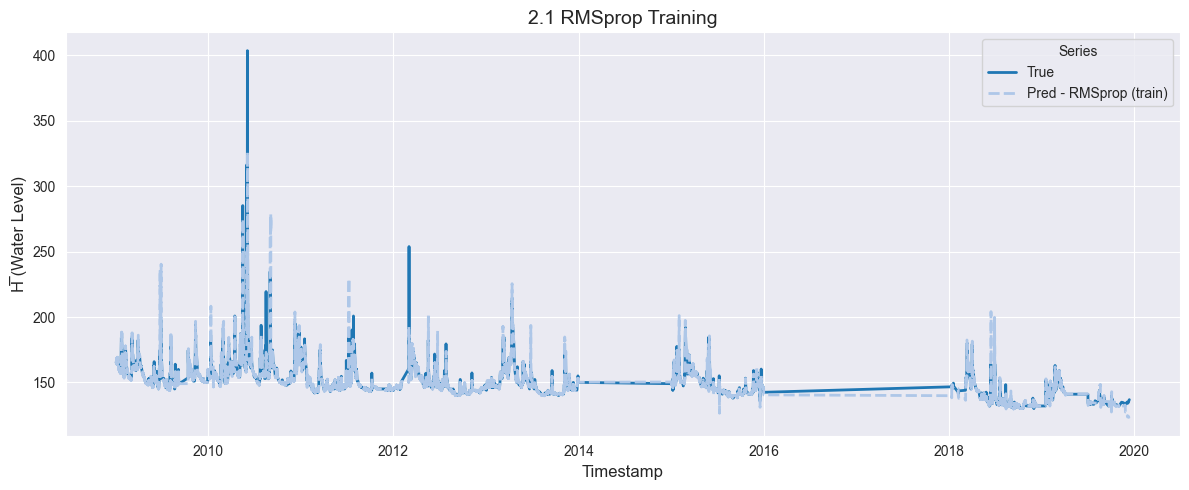

Appended metrics to CSV: results/training/online\p2_rmsprop.csv


In [21]:
import torch.optim as optim
torch.manual_seed(42)

model_rms, _, crit_rms = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_rms = optim.RMSprop(model_rms.parameters(), lr=1e-3, alpha=0.99)

y_tr_rms, y_pr_rms, idx_rms, losses_rms = uf.train_model_online(
    model_rms, opt_rms, crit_rms,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"RMSprop (train)": (y_tr_rms, y_pr_rms, idx_rms)},
    plot_title="2.1 RMSprop Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_rmsprop",
)

Testing complete.


============== FINAL COMPARISON ==============
RMSprop              | RMSE=4.0868 | MAE=1.1651 | R²=0.8601


Saved PNG: results/testing/online\p2_rmsprop.png


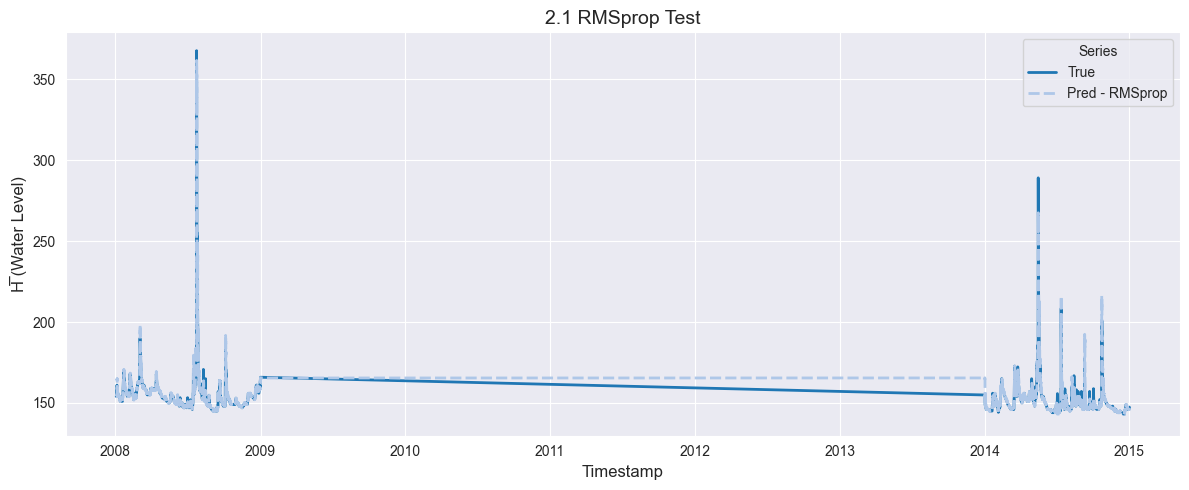

Appended metrics to CSV: results/testing/online\p2_rmsprop.csv
Exported results to CSV: results/testing/predictions_vs_true/online_RMSprop.csv


In [22]:
y_te_rms, y_pe_rms, idx_te_rms = uf.model_evaluate_with_norm(
    model_rms, crit_rms, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"RMSprop": (y_te_rms, y_pe_rms, idx_te_rms)},
    plot_title="2.1 RMSprop Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_rmsprop",
)
uf.export_results_to_csv(
    {"RMSprop": (y_te_rms, y_pe_rms, idx_te_rms)},
    "results/testing/predictions_vs_true/online"
)

## 2.2 : SGD + Momentum (+ Nesterov)


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 8.873158
   Batch 200/2461, Loss: 0.014284
   Batch 300/2461, Loss: 0.062695
   Batch 400/2461, Loss: 0.091230
   Batch 500/2461, Loss: 0.105168
   Batch 600/2461, Loss: 0.093287
   Batch 700/2461, Loss: 3.116392
   Batch 800/2461, Loss: 0.173698
   Batch 900/2461, Loss: 22.025879
   Batch 1000/2461, Loss: 2.454453
   Batch 1100/2461, Loss: 0.872356
   Batch 1200/2461, Loss: 0.392122
   Batch 1300/2461, Loss: 0.021613
   Batch 1400/2461, Loss: 2.568090
   Batch 1500/2461, Loss: 0.239515
   Batch 1600/2461, Loss: 3.229120
   Batch 1700/2461, Loss: 1.286945
   Batch 1800/2461, Loss: 0.007009
   Batch 1900/2461, Loss: 5.540292
   Batch 2000/2461, Loss: 0.286295
   Batch 2100/2461, Loss: 1.390753
   Batch 2200/2461, Loss: 0.326641
   Batch 2300/2461, Loss: 0.004862
   Batch 2400/2461, Loss: 0.065116
   Batch 2461/2461, Loss: 1.753610
Training complete.


============== FINAL COMPARISON ==============
SGD+Momentum (tr

Saved PNG: results/training/online\p2_sgd_momentum.png


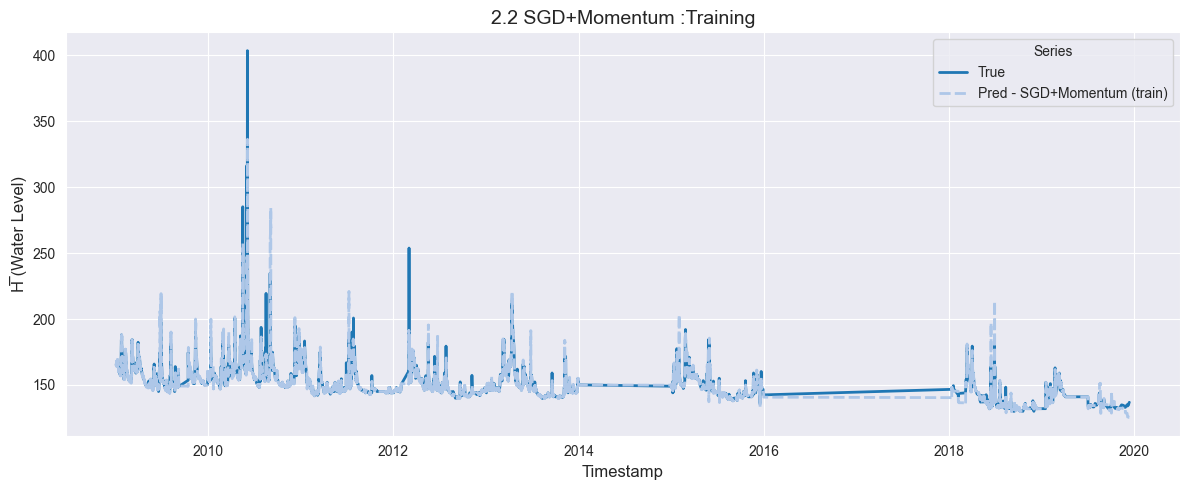

Appended metrics to CSV: results/training/online\p2_sgd_momentum.csv


In [23]:
torch.manual_seed(42)

model_sgd, _, crit_sgd = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=1e-2, momentum=0.9, nesterov=True)

y_tr_sgd, y_pr_sgd, idx_sgd, losses_sgd = uf.train_model_online(
    model_sgd, opt_sgd, crit_sgd,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"SGD+Momentum (train)": (y_tr_sgd, y_pr_sgd, idx_sgd)},
    plot_title="2.2 SGD+Momentum :Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_sgd_momentum",
)

Testing complete.


============== FINAL COMPARISON ==============
SGD+Momentum         | RMSE=5.5385 | MAE=1.3544 | R²=0.7430


Saved PNG: results/testing/online\p2_sgd_momentum.png


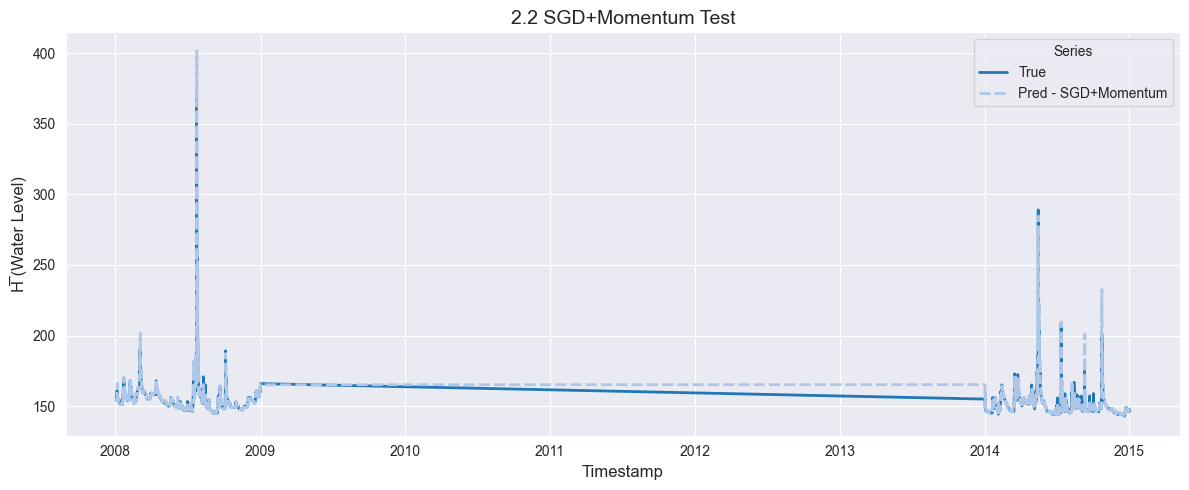

Appended metrics to CSV: results/testing/online\p2_sgd_momentum.csv
Exported results to CSV: results/testing/predictions_vs_true/online_SGD_Momentum.csv


In [24]:
y_te_sgd, y_pe_sgd, idx_te_sgd = uf.model_evaluate_with_norm(
    model_sgd, crit_sgd, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"SGD+Momentum": (y_te_sgd, y_pe_sgd, idx_te_sgd)},
    plot_title="2.2 SGD+Momentum Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_sgd_momentum",
)
uf.export_results_to_csv(
    {"SGD_Momentum": (y_te_sgd, y_pe_sgd, idx_te_sgd)},
    "results/testing/predictions_vs_true/online"
)

## 2.5 : Adam (low LR + weight decay)


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 12.930325
   Batch 200/2461, Loss: 0.049767
   Batch 300/2461, Loss: 0.081062
   Batch 400/2461, Loss: 0.528059
   Batch 500/2461, Loss: 0.108977
   Batch 600/2461, Loss: 0.007924
   Batch 700/2461, Loss: 4.006501
   Batch 800/2461, Loss: 0.014935
   Batch 900/2461, Loss: 23.198851
   Batch 1000/2461, Loss: 2.775992
   Batch 1100/2461, Loss: 3.730363
   Batch 1200/2461, Loss: 0.608595
   Batch 1300/2461, Loss: 0.059999
   Batch 1400/2461, Loss: 1.487908
   Batch 1500/2461, Loss: 0.171964
   Batch 1600/2461, Loss: 1.779627
   Batch 1700/2461, Loss: 1.792355
   Batch 1800/2461, Loss: 0.483494
   Batch 1900/2461, Loss: 5.244813
   Batch 2000/2461, Loss: 0.155965
   Batch 2100/2461, Loss: 1.462313
   Batch 2200/2461, Loss: 0.049141
   Batch 2300/2461, Loss: 0.129880
   Batch 2400/2461, Loss: 0.066475
   Batch 2461/2461, Loss: 2.288364
Training complete.


============== FINAL COMPARISON ==============
Adam-WD (train)

Saved PNG: results/training/online\p2_adam_wd.png


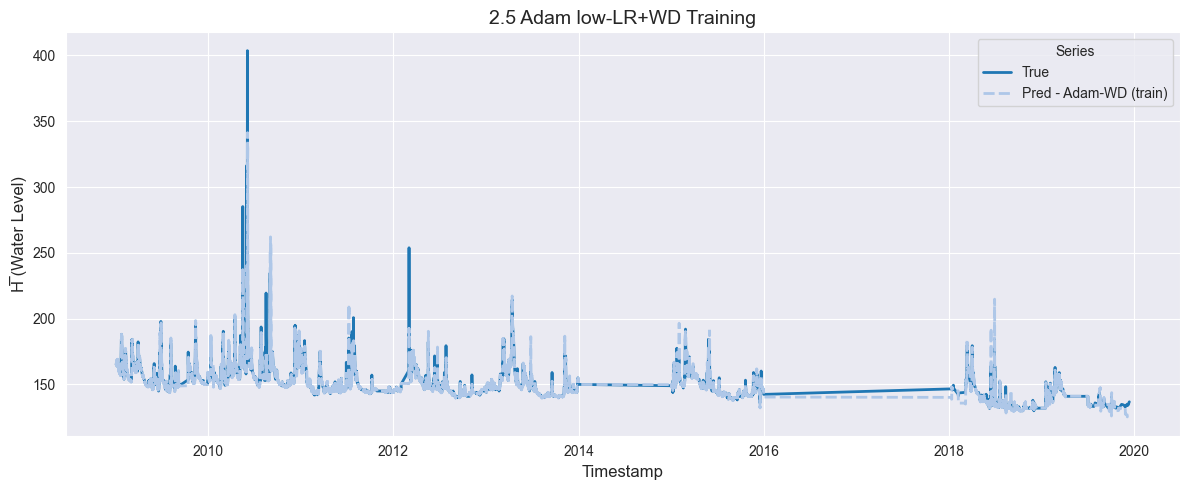

Appended metrics to CSV: results/training/online\p2_adam_wd.csv


In [25]:
torch.manual_seed(42)

model_adamwd, _, crit_adamwd = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_adamwd = optim.Adam(model_adamwd.parameters(), lr=1e-4, weight_decay=1e-4)

y_tr_awd, y_pr_awd, idx_awd, losses_awd = uf.train_model_online(
    model_adamwd, opt_adamwd, crit_adamwd,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"Adam-WD (train)": (y_tr_awd, y_pr_awd, idx_awd)},
    plot_title="2.5 Adam low-LR+WD Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_adam_wd",
)

Testing complete.


============== FINAL COMPARISON ==============
Adam-WD              | RMSE=6.0564 | MAE=1.2372 | R²=0.6927


Saved PNG: results/testing/online\p2_adam_wd.png


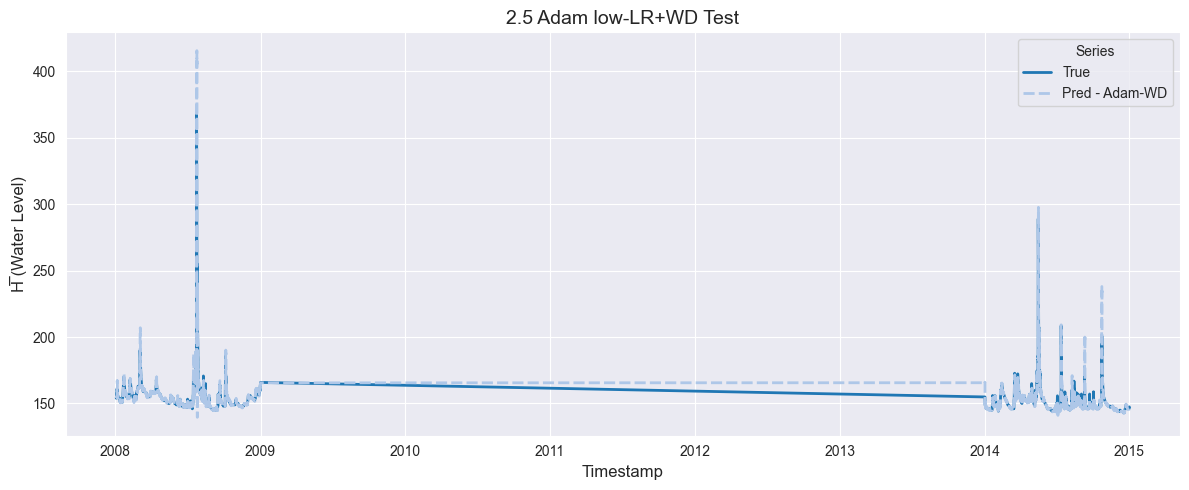

Appended metrics to CSV: results/testing/online\p2_adam_wd.csv
Exported results to CSV: results/testing/predictions_vs_true/online_Adam_WD.csv


In [26]:
y_te_awd, y_pe_awd, idx_te_awd = uf.model_evaluate_with_norm(
    model_adamwd, crit_adamwd, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"Adam-WD": (y_te_awd, y_pe_awd, idx_te_awd)},
    plot_title="2.5 Adam low-LR+WD Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_adam_wd",
)
uf.export_results_to_csv(
    {"Adam_WD": (y_te_awd, y_pe_awd, idx_te_awd)},
    "results/testing/predictions_vs_true/online"
)

## Phase 2 Summary of All Optimizers vs Test Set



============== FINAL COMPARISON ==============
RMSprop              | RMSE=4.0868 | MAE=1.1651 | R²=0.8601
SGD+Mom              | RMSE=5.5385 | MAE=1.3544 | R²=0.7430
Adam-WD              | RMSE=6.0564 | MAE=1.2372 | R²=0.6927


Saved PNG: results/testing/online\phase2_optimizer_comparison.png


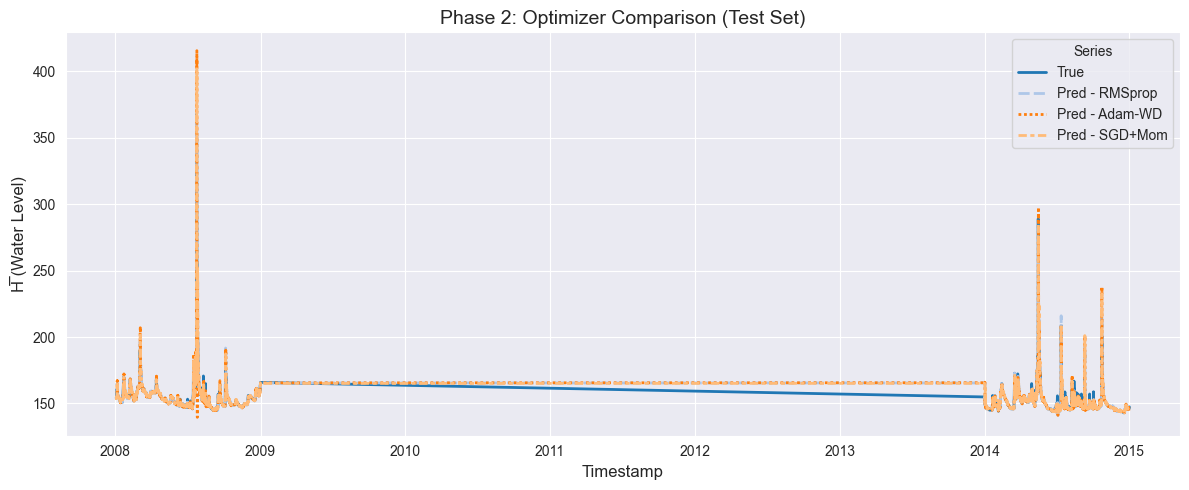

Appended metrics to CSV: results/testing/online\phase2_optimizer_comparison.csv


In [27]:
uf.calculate_metrics_and_plot(
    {
        "RMSprop":    (y_te_rms, y_pe_rms, idx_te_rms),
        "SGD+Mom":    (y_te_sgd, y_pe_sgd, idx_te_sgd),
        "Adam-WD":    (y_te_awd, y_pe_awd, idx_te_awd),
    },
    plot_title="Phase 2: Optimizer Comparison (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase2_optimizer_comparison",
)

# Phase 2b — Adam Hyperparameter Ablation
> **Fixed:** RollingNorm+clip, MLP, `max_grad_norm=1.0`
>
> | Knob | Lower | Higher |
> |---|---|---|
> | `beta1` | forgets gradients faster → better after drift | more momentum |
> | `beta2` | step size adapts faster to variance | slower adaptation |
> | `eps` | aggressive steps | conservative on calm periods |
> | `amsgrad` | — | monotone non-increasing LR (stable long-term) |

In [28]:
import importlib
import util_fun as uf
importlib.reload(uf)

ADAM_CONFIGS = [
    ("Adam-default",        dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b1=0.7",         dict(lr=1e-3, betas=(0.70, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b1=0.5",         dict(lr=1e-3, betas=(0.50, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b2=0.9",         dict(lr=1e-3, betas=(0.90, 0.900), eps=1e-8,  amsgrad=False)),
    ("Adam-eps=1e-4",       dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-4,  amsgrad=False)),
    ("Adam-amsgrad",        dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-8,  amsgrad=True)),
    ("Adam-b1=0.5-amsgrad", dict(lr=1e-3, betas=(0.50, 0.900), eps=1e-4,  amsgrad=True)),
    ("Adam-WD",             dict(lr=1e-4, betas=(0.90, 0.999), eps=1e-8,  amsgrad=False, weight_decay=1e-4)),
]

adam_test_results = {}
for label, kwargs in ADAM_CONFIGS:
    print(f"Running {label}...", end=" ", flush=True)
    torch.manual_seed(42)
    model_a, _, crit_a = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
    opt_a = optim.Adam(model_a.parameters(), **kwargs)

    uf.train_model_online(
        model_a, opt_a, crit_a,
        train_ds_roll, train_df,
        LOOKBACK, HORIZON, BATCH_SIZE,
        max_grad_norm=1.0, silent=True,
    )
    y_te_a, y_pe_a, idx_te_a = uf.model_evaluate_with_norm(
        model_a, crit_a, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
    )
    adam_test_results[label] = (y_te_a, y_pe_a, idx_te_a)
    uf.export_results_to_csv({label: (y_te_a, y_pe_a, idx_te_a)},
                             "results/testing/predictions_vs_true/online")
    print("done.")

print("\nAll Adam configs done.")

Running Adam-default... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-default.csv
done.
Running Adam-b1=0.7... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.7.csv
done.
Running Adam-b1=0.5... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.5.csv
done.
Running Adam-b2=0.9... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b2=0.9.csv
done.
Running Adam-eps=1e-4... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-eps=1e-4.csv
done.
Running Adam-amsgrad... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-amsgrad.csv
done.
Running Adam-b1=0.5-amsgrad... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.5-amsgrad.csv
done.
Running Adam-WD... Testing complete.
Exported results to CS



============== FINAL COMPARISON ==============
Adam-default         | RMSE=5.6625 | MAE=1.2047 | R²=0.7314
Adam-b1=0.7          | RMSE=4.4560 | MAE=1.1248 | R²=0.8337
Adam-b1=0.5          | RMSE=4.4538 | MAE=1.1312 | R²=0.8338
Adam-b2=0.9          | RMSE=5.0080 | MAE=1.1646 | R²=0.7899
Adam-eps=1e-4        | RMSE=5.5785 | MAE=1.2183 | R²=0.7393
Adam-amsgrad         | RMSE=5.1708 | MAE=1.1547 | R²=0.7760
Adam-b1=0.5-amsgrad  | RMSE=5.5527 | MAE=1.3563 | R²=0.7417
Adam-WD              | RMSE=6.0564 | MAE=1.2372 | R²=0.6927


Saved PNG: results/testing/online\phase2b_adam_ablation.png


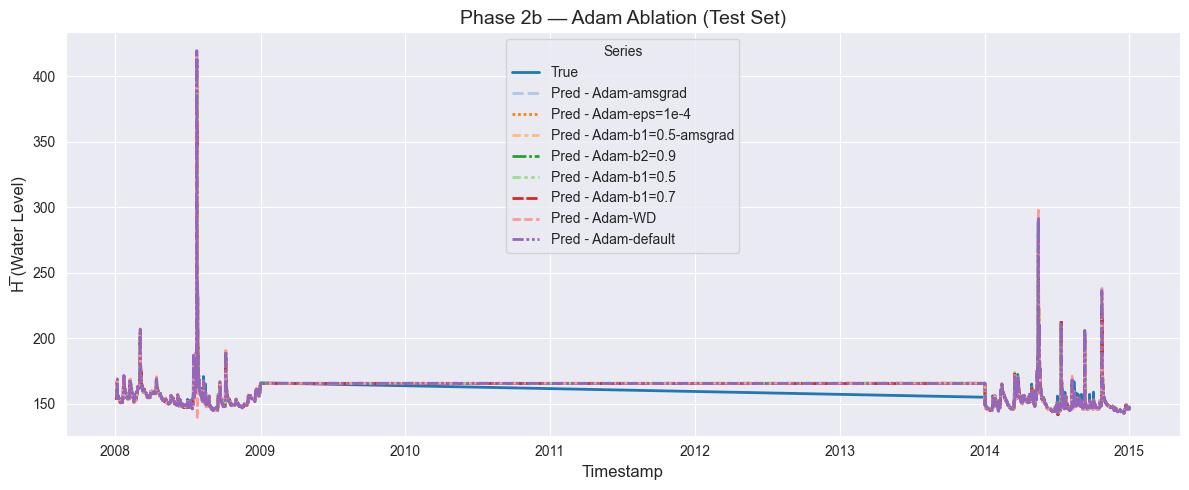

Appended metrics to CSV: results/testing/online\phase2b_adam_ablation.csv


In [29]:
uf.calculate_metrics_and_plot(
    adam_test_results,
    plot_title="Phase 2b — Adam Ablation (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase2b_adam_ablation",
)

# Phase 2c — FTRL (Follow The Regularized Leader)
> Custom PyTorch implementation in `cstm_models/ftrl.py`.
> Per-coordinate adaptive LR with L1/L2 built in — best theoretical online regret bounds.
>
> | Param | Role |
> |---|---|
> | `alpha` | Base learning rate |
> | `beta` | Smoothing — controls early-step LR (high β → conservative start) |
> | `lambda1` | L1 penalty → sparsity |
> | `lambda2` | L2 penalty → weight stability |

In [30]:
from cstm_models.ftrl import FTRL

FTRL_CONFIGS = [
    ("FTRL-default",      dict(alpha=0.01, beta=1.0, lambda1=0.0,   lambda2=0.0)),
    ("FTRL-l2=0.01",      dict(alpha=0.01, beta=1.0, lambda1=0.0,   lambda2=0.01)),
    ("FTRL-l1+l2",        dict(alpha=0.01, beta=1.0, lambda1=0.001, lambda2=0.01)),
    ("FTRL-alpha=0.1",    dict(alpha=0.1,  beta=1.0, lambda1=0.0,   lambda2=0.0)),
    ("FTRL-alpha=0.1-l2", dict(alpha=0.1,  beta=1.0, lambda1=0.0,   lambda2=0.01)),
]

ftrl_test_results = {}
for label, kwargs in FTRL_CONFIGS:
    print(f"Running {label}...", end=" ", flush=True)
    torch.manual_seed(42)
    model_f, _, crit_f = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
    opt_f = FTRL(model_f.parameters(), **kwargs)

    uf.train_model_online(
        model_f, opt_f, crit_f,
        train_ds_roll, train_df,
        LOOKBACK, HORIZON, BATCH_SIZE,
        max_grad_norm=1.0, silent=True,
    )
    y_te_f, y_pe_f, idx_te_f = uf.model_evaluate_with_norm(
        model_f, crit_f, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
    )
    ftrl_test_results[label] = (y_te_f, y_pe_f, idx_te_f)
    uf.export_results_to_csv({label: (y_te_f, y_pe_f, idx_te_f)},
                             "results/testing/predictions_vs_true/online")
    print("done.")

print("\nAll FTRL configs done.")

Running FTRL-default... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-default.csv
done.
Running FTRL-l2=0.01... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-l2=0.01.csv
done.
Running FTRL-l1+l2... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-l1+l2.csv
done.
Running FTRL-alpha=0.1... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-alpha=0.1.csv
done.
Running FTRL-alpha=0.1-l2... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_FTRL-alpha=0.1-l2.csv
done.

All FTRL configs done.




============== FINAL COMPARISON ==============
FTRL-default         | RMSE=3.4384 | MAE=1.1006 | R²=0.9010
FTRL-l2=0.01         | RMSE=3.4384 | MAE=1.1006 | R²=0.9010
FTRL-l1+l2           | RMSE=3.4384 | MAE=1.1006 | R²=0.9010
FTRL-alpha=0.1       | RMSE=5.3430 | MAE=1.3508 | R²=0.7609
FTRL-alpha=0.1-l2    | RMSE=5.1159 | MAE=1.3377 | R²=0.7808


Saved PNG: results/testing/online\phase2c_ftrl_ablation.png


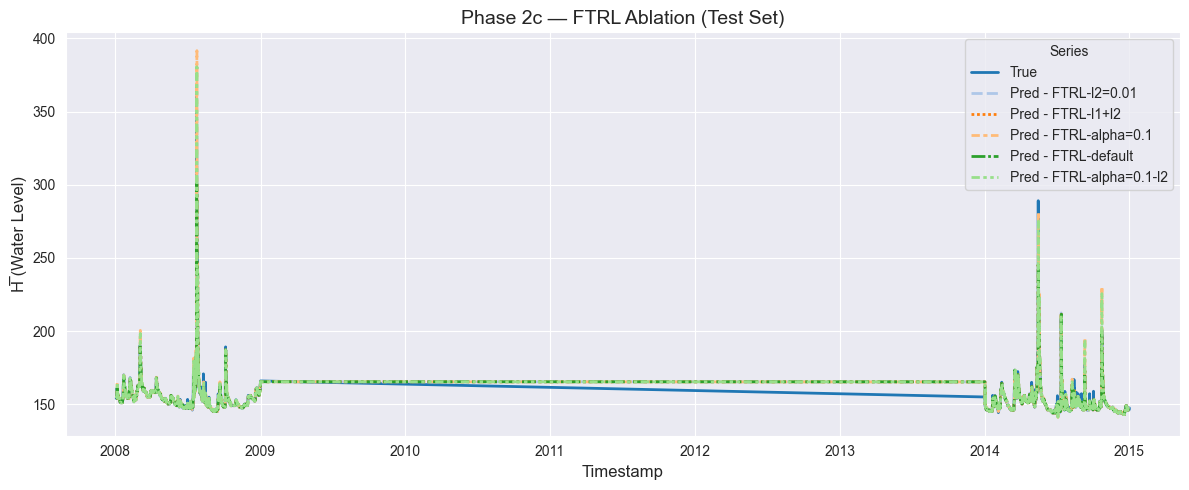

Appended metrics to CSV: results/testing/online\phase2c_ftrl_ablation.csv


In [31]:
uf.calculate_metrics_and_plot(
    ftrl_test_results,
    plot_title="Phase 2c — FTRL Ablation (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase2c_ftrl_ablation",
)

# Phase 3 — Peak Detection Analysis
> Metrics and zoom plots **restricted to flood-peak timesteps** (≥ 90th percentile of H_bar).
> Runs on the best Adam config + best FTRL config side by side.
> Update `all_peak_results` dict after Phase 2b/2c to include whichever configs you want compared.

In [ ]:
# Swap in winners after re-running with the new last-value-centered RollingNorm
BEST_ADAM_LABEL = "Adam-b1=0.7"   # Best Adam variant (RMSE=4.46, R²=0.834)
BEST_FTRL_LABEL = "FTRL-default"  # Best overall — flipped from worst to best after norm fix

all_peak_results = {
    "RollingNorm+Adam (baseline)": (y_te_roll, y_pe_roll, idx_te_roll),
    f"Best-Adam ({BEST_ADAM_LABEL})": adam_test_results[BEST_ADAM_LABEL],
    f"Best-FTRL ({BEST_FTRL_LABEL})": ftrl_test_results[BEST_FTRL_LABEL],
}

uf.peak_analysis(
    all_peak_results,
    peak_quantile=0.90,
    n_peaks=5,
    window_hours=72,
    export_file_name="results/testing/online/peak_analysis",
)

# Final Comparison — Offline vs Online
> **Argument:** Online ≈ offline on overall metrics, wins on peaks, costs a fraction of the compute.
>
> | Dimension | Offline | Online (MLP) |
> |---|---|---|
> | Training passes | Up to 500 epochs × full dataset | **1 pass**, batch_size=1 |
> | Adapts to new data | No — retrain from scratch | **Yes** — updates live |
> | Peak detection | Trained on historical distribution | **Sees each event as it arrives** |
> | Deployment | Periodic full retraining | **Runs on edge** |

In [36]:
import time
from cstm_models import build_lstm, build_gru, build_cnn

# Build flat test timestamps matching offline output shape
test_timestamps = []
for j in range(len(x_test)):
    start_idx = j * HORIZON + LOOKBACK
    test_timestamps.extend(list(test_df.index[start_idx: start_idx + HORIZON]))

OFFLINE_MODELS = [
    ("Offline-MLP",  build_mlp,  True),
    ("Offline-LSTM", build_lstm, False),
    ("Offline-GRU",  build_gru,  False),
    ("Offline-CNN",  build_cnn,  False),
]

offline_results = {}
offline_train_times = {}

for name, builder, needs_flatten in OFFLINE_MODELS:
    print(f"Training {name}...", end=" ", flush=True)
    torch.manual_seed(42)

    x_tr = x_train.reshape(len(x_train), -1) if needs_flatten else x_train
    x_te = x_test.reshape(len(x_test),   -1) if needs_flatten else x_test
    input_size = x_tr.shape[1] if needs_flatten else N_FEATURES

    model_off, opt_off, crit_off = builder(input_size=input_size, output_size=HORIZON)

    t0 = time.time()
    y_true_off, y_pred_off, ts_off = uf.train_model_offline(
        x_tr, y_train, x_te, y_test, test_timestamps,
        model_off, opt_off, crit_off,
        batch_size=32, max_epoch=500, early_Stop_threshold=10,
    )
    elapsed = time.time() - t0
    offline_train_times[name] = elapsed
    offline_results[name] = (y_true_off, y_pred_off, ts_off)
    print(f"done in {elapsed:.1f}s")

print("\nAll offline models done.")

Training Offline-MLP... 

Epoch 1/500  TrainLoss=0.001242  ValLoss=0.000455
Epoch 2/500  TrainLoss=0.000300  ValLoss=0.000336
Epoch 3/500  TrainLoss=0.000257  ValLoss=0.000351
Epoch 4/500  TrainLoss=0.000221  ValLoss=0.000272
Epoch 5/500  TrainLoss=0.000241  ValLoss=0.000314
Epoch 6/500  TrainLoss=0.000199  ValLoss=0.000251
Epoch 7/500  TrainLoss=0.000200  ValLoss=0.000232
Epoch 8/500  TrainLoss=0.000186  ValLoss=0.000263
Epoch 9/500  TrainLoss=0.000162  ValLoss=0.000246
Epoch 10/500  TrainLoss=0.000156  ValLoss=0.000218
Epoch 11/500  TrainLoss=0.000147  ValLoss=0.000193
Epoch 12/500  TrainLoss=0.000140  ValLoss=0.000193
Epoch 13/500  TrainLoss=0.000129  ValLoss=0.000193
Epoch 14/500  TrainLoss=0.000119  ValLoss=0.000198
Epoch 15/500  TrainLoss=0.000130  ValLoss=0.000226
Epoch 16/500  TrainLoss=0.000141  ValLoss=0.000233
Epoch 17/500  TrainLoss=0.000126  ValLoss=0.000181
Epoch 18/500  TrainLoss=0.000112  ValLoss=0.000175
Epoch 19/500  TrainLoss=0.000113  ValLoss=0.000179
Epoch 20/500  TrainLoss=0.000126  ValLos

In [ ]:
# Overall winner after norm fix: FTRL-default (RMSE=3.44, R²=0.901)
# Also include Adam-default (best peak detection: Peak-R²=0.80)
ONLINE_BEST_OVERALL = "FTRL-default"     # from ftrl_test_results
ONLINE_BEST_PEAKS   = "Adam-default"     # from adam_test_results — paradox: worse RMSE, better peaks

grand_results = {
    f"Online-{ONLINE_BEST_OVERALL}":  ftrl_test_results[ONLINE_BEST_OVERALL],
    f"Online-{ONLINE_BEST_PEAKS}":    adam_test_results[ONLINE_BEST_PEAKS],
    **offline_results,
}

uf.calculate_metrics_and_plot(
    grand_results,
    plot_title="Grand Comparison — Offline vs Online (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/grand_comparison",
)

print("\n=== Compute Cost ===")
print(f"{'Online-MLP (1 pass)':30s}  ~{len(x_train)} steps  (no epochs)")
for name, t in offline_train_times.items():
    print(f"{name:30s}  {t:.1f}s")

Peak threshold (90th pct): 160.5833

Method                     Peak-RMSE   Peak-MAE  Peak-R²
---------------------------------------------------------
Online-MLP (Adam-b1=0.7)     12.8592     5.6392   0.7112
Offline-MLP                  12.2760     6.0977   0.7589
Offline-LSTM                 13.0754     6.8267   0.7265
Offline-GRU                  13.1912     6.4175   0.7216
Offline-CNN                  20.9559    10.2647   0.2974

Saved peak metrics: results/testing/online/grand_peak_analysis_peak_metrics.csv

Top-5 peaks:
  2008-07-23 17:00:00  H_bar=367.6300
  2014-05-16 01:00:00  H_bar=289.0600
  2014-07-12 20:00:00  H_bar=208.5500
  2014-10-23 15:00:00  H_bar=200.7900
  2008-03-03 00:00:00  H_bar=190.0000
Saved: results/testing/online/grand_peak_analysis_peak1.png


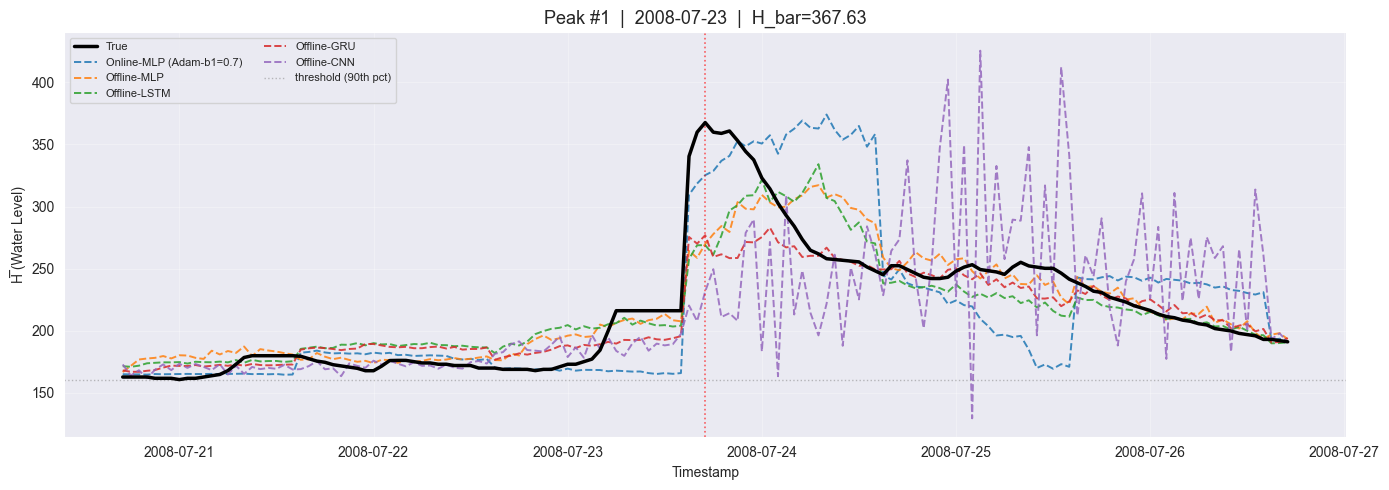

Saved: results/testing/online/grand_peak_analysis_peak2.png


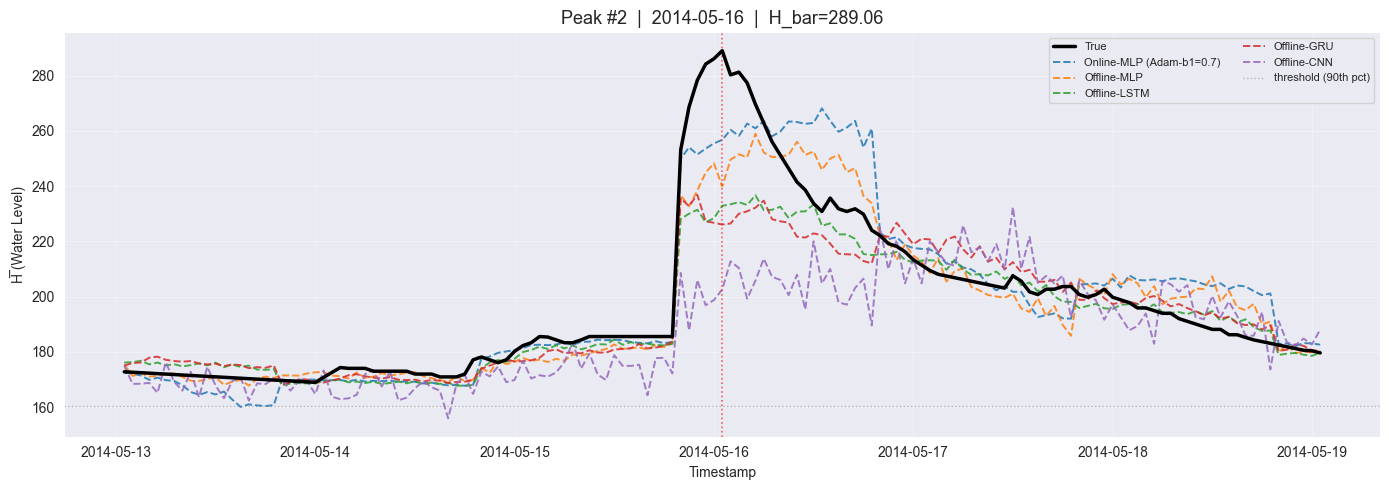

Saved: results/testing/online/grand_peak_analysis_peak3.png


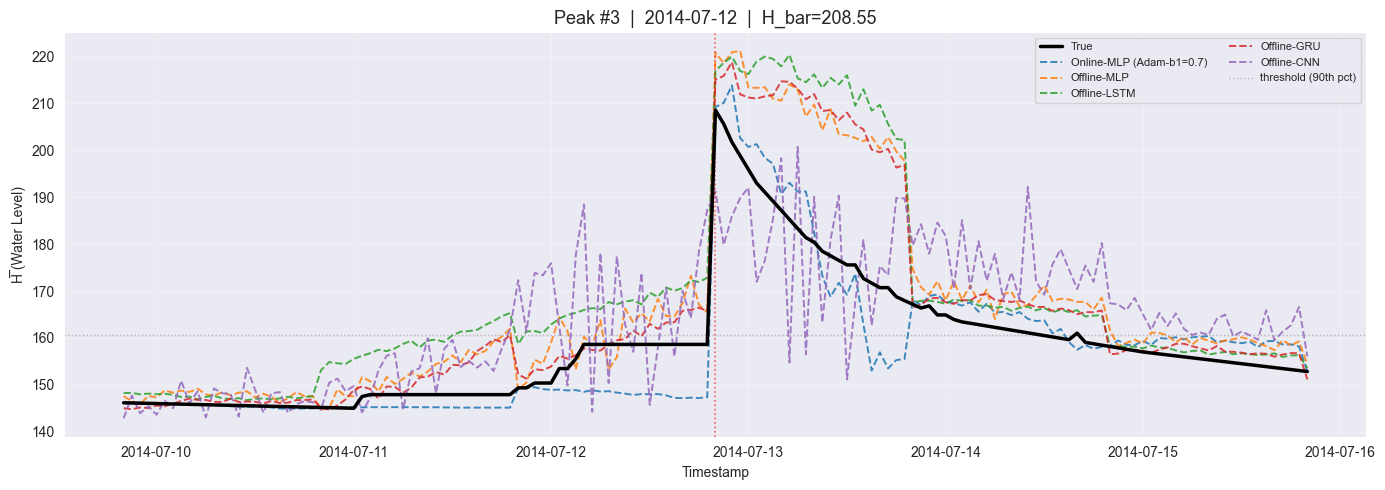

Saved: results/testing/online/grand_peak_analysis_peak4.png


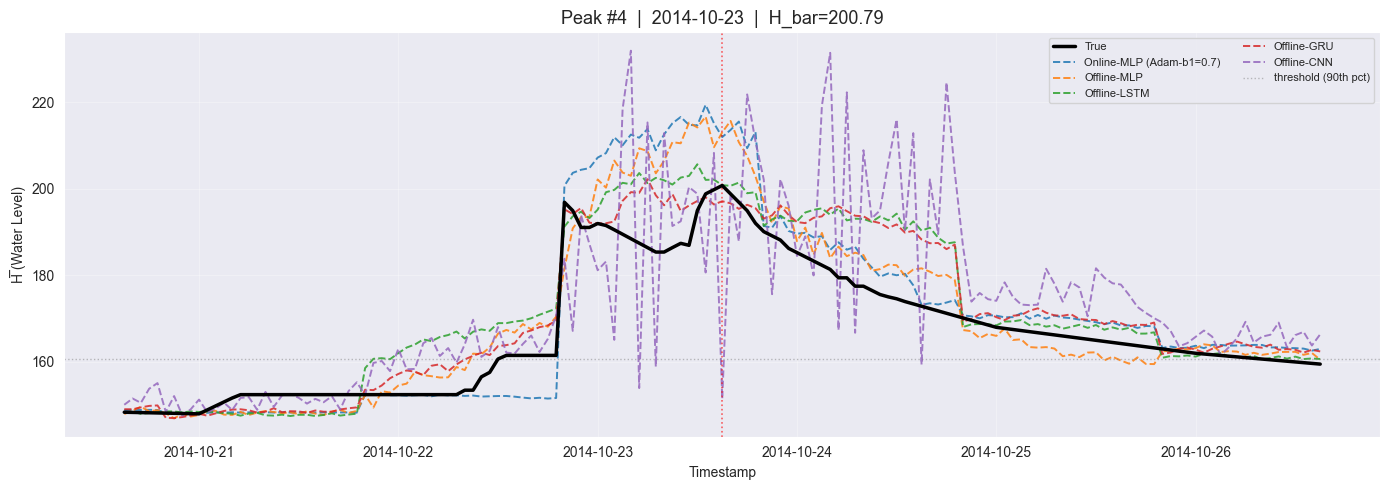

Saved: results/testing/online/grand_peak_analysis_peak5.png


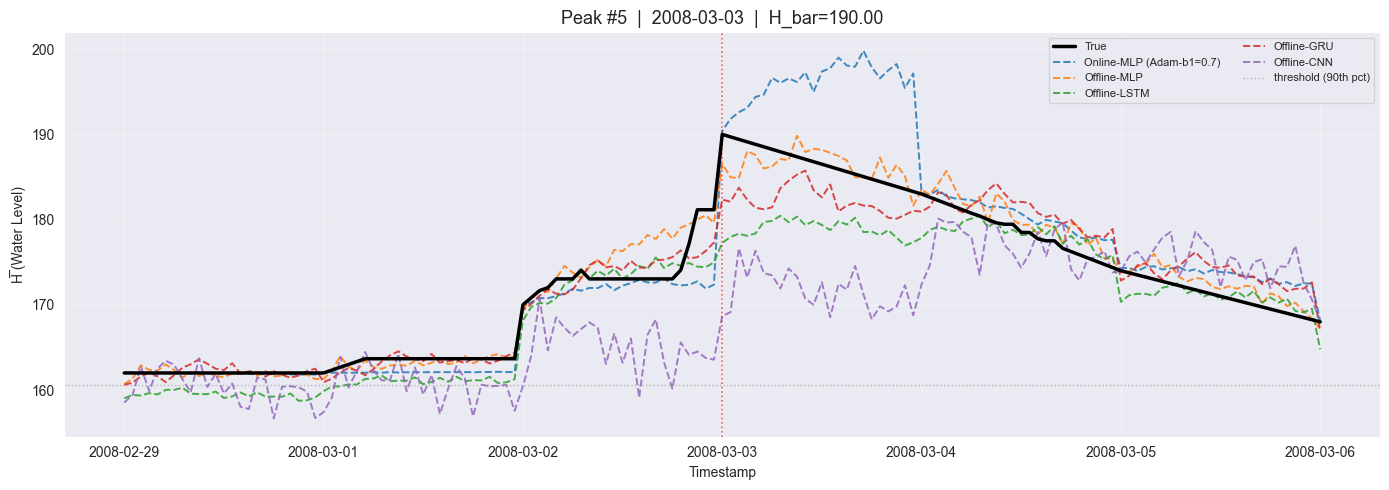

In [35]:
uf.peak_analysis(
    grand_results,
    peak_quantile=0.90,
    n_peaks=5,
    window_hours=72,
    export_file_name="results/testing/online/grand_peak_analysis",
)